
Model: Linear Regression
MAE: 49792.04483116162
RMSE: 63318.87438774143
R2: -0.00048212068431596755

Model: Random Forest
MAE: 55916.022106052915
RMSE: 71331.86744443842
R2: -0.2697263953438518

Model: Gradient Boosting
MAE: 49900.183930460764
RMSE: 63562.85676929167
R2: -0.008207156859890263

Saved Results Table


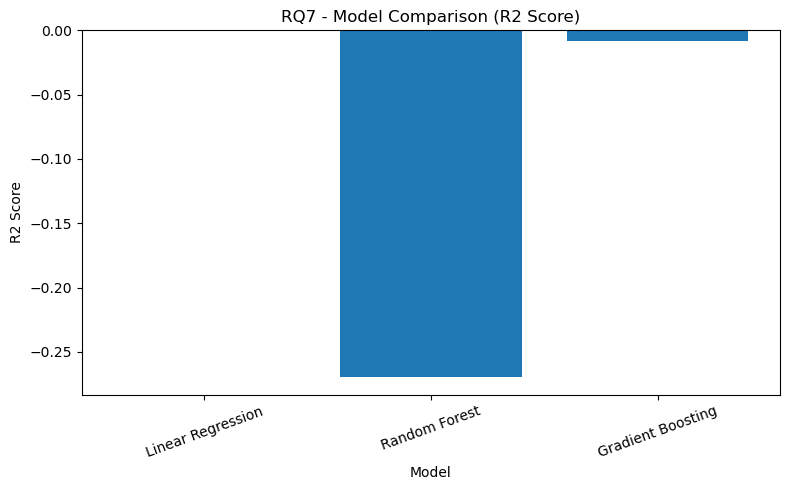

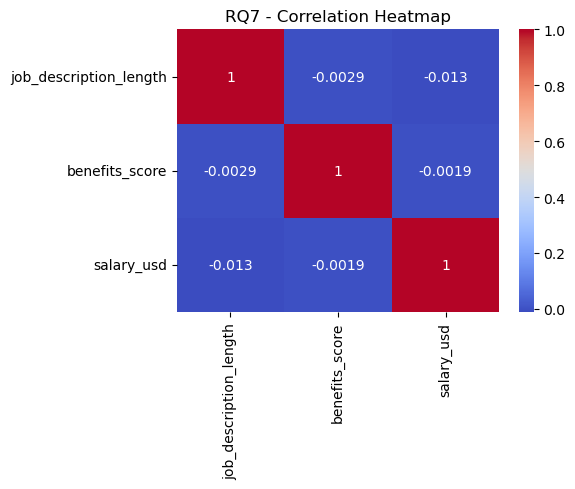

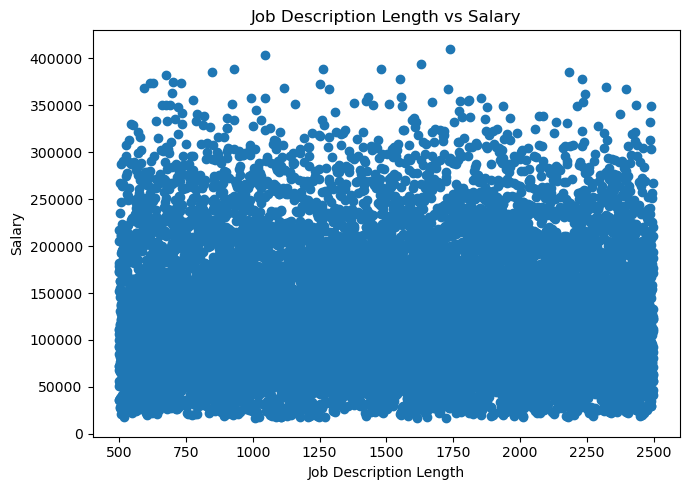


Feature Importance:
                  Feature  Importance
0  job_description_length     0.66967
1          benefits_score     0.33033

Dataset copied successfully to:
E:\ML ASSIGNMENT 2\ai_job_dataset_RQ7.csv

RQ7 COMPLETED SUCCESSFULLY
All models, figures, and tables saved.


In [1]:

# RQ7: Salary Prediction using Job Description + Benefits


import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

df = pd.read_csv("ai_job_dataset1.csv")

base_path = r"E:\ML ASSIGNMENT 2"

models_path = os.path.join(base_path, "models")
tables_path = os.path.join(base_path, "tables")

os.makedirs(models_path, exist_ok=True)
os.makedirs(tables_path, exist_ok=True)

rq7_data = df[[
    "job_description_length",
    "benefits_score",
    "salary_usd"
]].dropna()

rq7_data.to_csv(os.path.join(tables_path, "RQ7_dataset.csv"), index=False)

X = rq7_data[["job_description_length", "benefits_score"]]
y = rq7_data["salary_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    results.append([name, mae, mse, rmse, r2])

    print("\n==============================")
    print("Model:", name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

results_df = pd.DataFrame(results, columns=[
    "Model", "MAE", "MSE", "RMSE", "R2 Score"
])

results_df.to_csv(
    os.path.join(tables_path, "RQ7_model_comparison.csv"),
    index=False
)

print("\nSaved Results Table")

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.title("RQ7 - Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(os.path.join(models_path, "RQ7_model_comparison.png"))
plt.show()

import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(rq7_data.corr(), annot=True, cmap="coolwarm")

plt.title("RQ7 - Correlation Heatmap")

plt.tight_layout()

plt.savefig(os.path.join(models_path, "RQ7_correlation_heatmap.png"))
plt.show()

plt.figure(figsize=(7,5))

plt.scatter(rq7_data["job_description_length"], rq7_data["salary_usd"])
plt.title("Job Description Length vs Salary")
plt.xlabel("Job Description Length")
plt.ylabel("Salary")

plt.tight_layout()

plt.savefig(os.path.join(models_path, "RQ7_description_vs_salary.png"))
plt.show()

rf_model = models["Random Forest"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance.to_csv(
    os.path.join(tables_path, "RQ7_feature_importance.csv"),
    index=False
)

print("\nFeature Importance:")
print(importance)

destination = os.path.join(base_path, "ai_job_dataset_RQ7.csv")

shutil.copy("ai_job_dataset1.csv", destination)

print("\nDataset copied successfully to:")
print(destination)

print("\nRQ7 COMPLETED SUCCESSFULLY")
print("All models, figures, and tables saved.")